# Brass — Physical Modelling from First Principles
### One self-contained notebook: physics → engine → playable instrument → tuning recipes

This notebook builds a brass instrument by **simulating the acoustics**, not by
sampling. Everything runs from the single setup cell below — no external files
to import. It walks the brass milestone ladder (B0→B7), proving each step
**empirically** (impulse-test the resonator, look at where the modes land, then
listen), and finishes with **tuning recipes** for specific instruments and
sounds.

Two layers, kept deliberately separate:
- **Analysis** — *why* brass works: transfer-matrix input impedance + a
  Kelly–Lochbaum waveguide bore, two independent methods that agree.
- **Synthesis** — *making it playable*: a self-oscillating waveguide voice,
  nonlinear brassiness, a continuous slide, mutes and directivity.

> **Run order:** execute the setup cell first, then top to bottom. Every audio
> cell renders an inline player.

## Setup — the whole engine in one cell

The complete physical-modelling library. Every non-trivial line is traceable to
a physical principle (a reflection, a delay, an impedance, a resonance); read the
comments as the theory. After the definitions we alias the module name `brass`
to this notebook's namespace so the rest of the cells read naturally.

In [1]:
"""
brass.py  --  Physical-modelling brass synthesis, first principles.

Companion code to BRASS_TRACK.md. Two layers, kept deliberately separate:

  ANALYSIS layer  (why brass instruments work)
      - transfer-matrix input impedance  -> where the resonances sit
      - Kelly-Lochbaum waveguide bore     -> same physics, time domain
    These PROVE the central claim of the charter: a bare cylinder gives an
    odd-only, non-harmonic resonance comb (useless); a flaring bell drags the
    low modes up into an (almost) full harmonic series with a weak/virtual
    fundamental. Both methods are validated against closed-form theory.

  SYNTHESIS layer (making a playable sound)
      - a self-oscillating waveguide voice (McIntyre-Schumacher-Woodhouse reed,
        the robust STK-Clarinet reflection form) primed into a chosen register
      - nonlinear wave-steepening for 'brassiness'
      - continuous fractional-delay slide (trombone)

    The self-oscillating LIP model (single-mass Bernoulli valve) is the
    physically 'correct' source, but a one-mass lip is a research-grade tuning
    problem to keep locked across the whole register (it drifts into its own
    high-frequency limit cycle). The reed-reflection source below oscillates
    reliably and tracks pitch, so it is what actually renders audio here.
    That honesty is deliberate (working-agreement principle 4).
"""
import numpy as np
from scipy.signal import butter, sosfilt

# --- physical constants -----------------------------------------------------
C_SOUND = 343.0      # m/s
RHO     = 1.204      # kg/m^3
FS      = 44100.0    # Hz


# ===========================================================================
#  small stateful filters
# ===========================================================================
class OnePole:
    """One-pole low-pass. Frequency-dependent loss: highs die faster than lows
       every round trip, exactly as real wall/radiation losses behave (2.4)."""
    def __init__(self, g=0.05): self.g = g; self.y = 0.0
    def tick(self, x):
        self.y = (1 - self.g) * x + self.g * self.y
        return self.y

class OneZero:
    """One-zero low-pass loss (gentler slope, used in the reed loop)."""
    def __init__(self, g=0.6): self.g = g; self.p = 0.0
    def tick(self, x):
        y = self.g * x + (1 - self.g) * self.p; self.p = x; return y

class DCBlock:
    """Removes the DC that a rectifying nonlinearity pumps into the loop (6.4)."""
    def __init__(self, R=0.99): self.R = R; self.x1 = 0.0; self.y1 = 0.0
    def tick(self, x):
        y = x - self.x1 + self.R * self.y1; self.x1 = x; self.y1 = y; return y


class Delay:
    """Fractional delay line, linear interpolation. The fractional read is what
       lets a trombone slide move *continuously* between pitches (2.8, 6.1)."""
    def __init__(self, maxlen=8192):
        self.buf = np.zeros(maxlen); self.n = maxlen; self.wr = 0; self.delay = 100.0
    def set_delay(self, d): self.delay = max(1.0, min(self.n - 2, d))
    def last_out(self):
        rd = self.wr - self.delay
        i = int(np.floor(rd)); frac = rd - i
        a = self.buf[i % self.n]; b = self.buf[(i + 1) % self.n]
        return a + frac * (b - a)
    def tick(self, x):
        o = self.last_out(); self.buf[self.wr % self.n] = x; self.wr += 1; return o


# ===========================================================================
#  ANALYSIS 1 -- transfer-matrix input impedance
# ===========================================================================
# Each short cylinder is a two-port (ABCD) relating (pressure, volume-flow) at
# its ends. Any flare/cone is just many short cylinders in cascade (2.5). The
# reed/lip sits at a pressure antinode, so the notes it can play are the MAXIMA
# of |Z_in| seen from the mouthpiece.
def cyl_matrix(f, length, area):
    w = 2 * np.pi * f
    a = np.sqrt(area / np.pi)
    alpha = (1.0 / (C_SOUND * a)) * np.sqrt(w) * 3.0e-5 * np.sqrt(2)   # wall loss
    k = w / C_SOUND - 1j * alpha
    Z0 = RHO * C_SOUND / area
    kl = k * length
    return np.array([[np.cos(kl),      1j * Z0 * np.sin(kl)],
                     [1j * np.sin(kl) / Z0, np.cos(kl)]], dtype=complex)

def radiation_load(f, area_end):
    """Unflanged open pipe radiation impedance, low-ka approximation."""
    a = np.sqrt(area_end / np.pi)
    k = 2 * np.pi * f / C_SOUND
    Z0 = RHO * C_SOUND / area_end
    ka = k * a
    return Z0 * ((ka ** 2) / 4.0 + 1j * 0.6133 * ka)

def input_impedance(freqs, profile):
    """profile: list of (length_m, area_m2) slices, mouthpiece end first."""
    Zin = np.zeros(len(freqs), dtype=complex)
    for i, f in enumerate(freqs):
        M = np.eye(2, dtype=complex)
        for (L, S) in profile:
            M = M @ cyl_matrix(f, L, S)
        Zrad = radiation_load(f, profile[-1][1])
        A, B, Cc, D = M[0, 0], M[0, 1], M[1, 0], M[1, 1]
        Zin[i] = (A * Zrad + B) / (Cc * Zrad + D)
    return Zin

def discretize(x, radius):
    """(x[m], radius[m]) polyline -> short-cylinder (length, area) slices."""
    return [ (x[i+1]-x[i], np.pi*(0.5*(radius[i]+radius[i+1]))**2)
             for i in range(len(x)-1) ]


# ===========================================================================
#  ANALYSIS 2 -- Kelly-Lochbaum waveguide bore (time domain)
# ===========================================================================
class KLBore:
    """N one-sample sections over a cross-sectional-area array. Between section
       i and i+1 the pressure reflection is  r = (A_i - A_{i+1})/(A_i + A_{i+1}).
       A widening (a cone, the bell) gives r<0: a partial, inverting reflection
       at every step. Those cumulative negative reflections are exactly what
       redistributes the modes into a harmonic series (2.3-2.5, 6.5).
       Validated: a bare cylinder rings at c/4L with clean odd harmonics."""
    def __init__(self, areas, loss_g=0.03, bell_reflect=0.9):
        self.N = len(areas); self.A = np.asarray(areas, float)
        self.k = (self.A[:-1] - self.A[1:]) / (self.A[:-1] + self.A[1:])
        self.pr = np.zeros(self.N); self.pl = np.zeros(self.N)
        self.loss = OnePole(loss_g); self.br = bell_reflect
    def step(self, inject, r_mouth=1.0):
        k = self.k
        w = k * (self.pr[:-1] - self.pl[1:])          # one-multiply scattering
        pr = np.empty(self.N); pl = np.empty(self.N)
        pr[1:] = self.pr[:-1] + w                     # right-goers advance
        pl[:-1] = self.pl[1:] + w                     # left-goers advance
        pr[0] = inject + r_mouth * self.pl[0]         # closed-ish mouthpiece
        pl[-1] = -self.br * self.loss.tick(self.pr[-1])  # bell: low-pass, invert
        self.pr, self.pl = pr, pl
        radiated = (1 - self.br) * self.pr[-1]
        return radiated, self.pr[0] + self.pl[0]

def impulse_response(bore, seconds=0.6, r_mouth=1.0):
    n = int(FS * seconds); out = np.zeros(n)
    for i in range(n):
        out[i], _ = bore.step(1.0 if i == 0 else 0.0, r_mouth)
    return out

def resonances(sig, height=0.05, min_hz=30, n_peaks=10):
    from scipy.signal import find_peaks
    w = np.hanning(len(sig))
    sp = np.abs(np.fft.rfft(sig * w)); fr = np.fft.rfftfreq(len(sig), 1 / FS)
    pk, _ = find_peaks(sp / sp.max(), height=height,
                       distance=int(min_hz * len(sig) / FS))
    return fr[pk][:n_peaks], (sp / sp.max())[pk][:n_peaks]


# ===========================================================================
#  bore geometry builders
# ===========================================================================
def cyl_areas(length, radius):
    dx = C_SOUND / FS
    N = max(4, int(round(length / dx)))
    return np.full(N, np.pi * radius * radius)

def trumpet_polyline(gamma=0.75, body=0.85, Lbell=0.28,
                     r_throat=0.002, r_bore=0.0055, r_mouth=0.062):
    """Leadpipe taper -> cylindrical body -> Bessel-horn bell flare.
       gamma/body tuned so modes 3-6 align near-harmonically (validated)."""
    xs, rs = [], []
    n = 40
    for i in range(n):
        t = i / (n - 1); xs.append(0.25 * t); rs.append(r_throat + (r_bore - r_throat) * t)
    x0 = 0.25
    n = 120
    for i in range(1, n):
        t = i / (n - 1); xs.append(x0 + body * t); rs.append(r_bore)
    x0 += body
    n = 90
    for i in range(1, n):
        t = i / (n - 1)
        r = r_bore + (r_mouth - r_bore) * (t ** (1 / (1 - gamma)))
        xs.append(x0 + Lbell * t); rs.append(r)
    return np.array(xs), np.array(rs)

def polyline_to_areas(xs, rs):
    dx = C_SOUND / FS
    N = int(round(xs[-1] / dx)); g = np.linspace(0, xs[-1], N)
    return np.pi * np.interp(g, xs, rs) ** 2


# ===========================================================================
#  B3 -- the mouthpiece (Helmholtz resonator / "brass formant")
# ===========================================================================
# A brass mouthpiece is a wide cup narrowing sharply to a small throat: a
# volume (cup) feeding a short narrow neck (throat/backbore) -- a Helmholtz
# resonator, f = (c/2pi)*sqrt(A/(V*L_eff)). Its single broad resonance sits
# ABOVE the playing modes (~800-1200 Hz for a trumpet) and boosts the response
# there: this is the "brass formant" that gives the family its bright ring and
# makes the upper register speak. Default geometry below pops at ~930 Hz,
# validated by the matched pop-test (radiate the cup+throat into free air and
# read its peak) and cross-checked against the analytic Helmholtz formula.
def mouthpiece_polyline(r_cup=0.009, cup_depth=0.011, r_throat=0.0018, throat_len=0.011):
    xs = np.array([0.0, cup_depth, cup_depth, cup_depth + throat_len])
    rs = np.array([r_cup, r_cup, r_throat, r_throat])
    return xs, rs

def prepend_mouthpiece(xs, rs, **kw):
    """Splice a mouthpiece onto the front (mouthpiece end) of a bore polyline."""
    mxs, mrs = mouthpiece_polyline(**kw)
    return np.concatenate([mxs, mxs[-1] + xs]), np.concatenate([mrs, rs])

def mouthpiece_pop(r_cup=0.009, cup_depth=0.011, r_throat=0.0018, throat_len=0.011):
    """The 'pop test': the cup+throat's own resonance, radiating into free air.
       This is exactly what a player hears popping a palm over the mouthpiece."""
    prof = [(cup_depth, np.pi * r_cup ** 2), (throat_len, np.pi * r_throat ** 2)]
    fr = np.linspace(50, 3000, 12000)
    Z = np.zeros(len(fr), dtype=complex)
    for i, f in enumerate(fr):
        M = np.eye(2, dtype=complex)
        for (L, S) in prof:
            M = M @ cyl_matrix(f, L, S)
        Zl = radiation_load(f, np.pi * r_throat ** 2)
        Z[i] = (M[0, 0] * Zl + M[0, 1]) / (M[1, 0] * Zl + M[1, 1])
    return fr[np.argmax(np.abs(Z))]


# ===========================================================================
#  SYNTHESIS -- self-oscillating waveguide voice
# ===========================================================================
def reed_table(x, offset=0.7, slope=-0.44):
    """Nonlinear valve reflection coefficient vs pressure difference. This is
       the reed/lip that COUPLES to the acoustic state of the bore -- the exact
       reason a linear/modal source cannot replace the waveguide (charter 2.1,
       working-agreement note). Clipped at 1.0 (valve fully open)."""
    return min(1.0, offset + slope * x)

class Voice:
    """Self-oscillating pressure-controlled valve on a bore. Primed into the
       target register (= 'setting the embouchure') so it locks to the intended
       mode instead of overblowing. Renders robust, pitch-tracking tones."""
    def __init__(self, freq, loss_g=0.6, refl=0.95, breath=0.5,
                 offset=0.7, slope=-0.44, prime=True, seed=1):
        self.d = Delay(); self.d.set_delay(FS / (2 * freq))
        self.lp = OneZero(loss_g); self.dc = DCBlock()
        self.refl = refl; self.breath = breath
        self.offset = offset; self.slope = slope
        self.rng = np.random.default_rng(seed)
        if prime:
            L = self.d.n; idx = np.arange(L)
            self.d.buf[:] = 0.05 * np.sin(2 * np.pi * freq * idx / FS)
            self.d.wr = int(np.ceil(self.d.delay)) + 1
    def set_delay_samples(self, d): self.d.set_delay(d)      # for the slide
    def tick(self, breath_env=1.0, noise=0.012):
        b = self.breath * breath_env
        b = b + b * noise * self.rng.standard_normal()
        out = -self.refl * self.lp.tick(self.d.last_out())   # reflect + loss
        pd = out - b                                         # pressure across reed
        rc = reed_table(pd, self.offset, self.slope)
        val = b + rc * pd                                    # MSW update
        self.d.tick(val)
        return self.dc.tick(val)

def render_note(freq, seconds=1.0, attack=0.05, release=0.1, **kw):
    v = Voice(freq, **kw)
    n = int(FS * seconds); out = np.zeros(n)
    a = int(FS * attack); r = int(FS * release)
    for i in range(n):
        env = min(1.0, i / max(1, a))
        if i > n - r: env *= max(0.0, (n - i) / r)
        out[i] = v.tick(env)
    return out


# ===========================================================================
#  SYNTHESIS -- brassiness (nonlinear wave steepening, 2.7)
# ===========================================================================
def brassiness(sig, drive=0.0):
    """A LINEAR waveguide can never sound brassy: it cannot create the high
       harmonics that a steepening (near-shock) wavefront produces at high blow.
       Real brass steepens because wave speed rises with local amplitude, so
       peaks catch up on troughs. This is the reduced 1-D model of that effect:
       an amplitude-dependent waveshaper whose harmonic generation grows with
       playing level. drive=0 -> transparent (pp); large drive -> bright (ff).
       (Full physics = a Burgers/Menguy-Gilbert nonlinear propagation stage.)"""
    if drive <= 0: return sig
    x = sig / (np.max(np.abs(sig)) + 1e-9)
    y = np.tanh(x * (1 + drive)) / np.tanh(1 + drive)   # level-dependent steepening
    return y * (np.max(np.abs(sig)) + 1e-9)


# ===========================================================================
#  SYNTHESIS -- trombone slide (continuous fractional delay, 2.8)
# ===========================================================================
def render_slide(f_start, f_end, seconds=1.2, smooth_ms=8.0, **kw):
    """A slide is not a series of discrete pitches -- it is one bore whose
       LENGTH changes continuously. Only a fractional delay can do that; the
       delay length is smoothed to avoid zipper noise on the moving read."""
    v = Voice(f_start, **kw)
    n = int(FS * seconds); out = np.zeros(n)
    d0 = FS / (2 * f_start); d1 = FS / (2 * f_end)
    a = 1.0 - np.exp(-1.0 / (smooth_ms * 0.001 * FS))    # one-pole smoother
    d = d0
    for i in range(n):
        t = i / n
        target = FS / (2 * (f_start + (f_end - f_start) * t))
        d += a * (target - d); v.set_delay_samples(d)
        env = min(1.0, i / (0.04 * FS))
        out[i] = v.tick(env)
    return out


# ===========================================================================
#  B7 -- mutes + directivity (2.9)
# ===========================================================================
# MUTE. An object wedged in the bell does two audible things: (1) it blocks the
# wide-band low-frequency escape, so lows reflect back down the bore instead of
# radiating -> a high-passed, pinched, nasal timbre; (2) it adds its OWN cavity
# resonance, a strong mid/high formant that is the mute's characteristic
# "voice". The felt back-reaction slightly retunes the horn (players lip it
# back), but the audible signature is this radiation-side colouring, modelled
# here on the radiated output. Each mute is a (formant peak, sharpness Q,
# low-cut, boost) fingerprint.
MUTES = {
    "straight": dict(peak=1800.0, Q=2.5, hp=600.0, gain=1.6),  # bright, pinched
    "cup":      dict(peak=1100.0, Q=1.4, hp=350.0, gain=1.0),  # darker, veiled
    "harmon":   dict(peak=2400.0, Q=4.0, hp=900.0, gain=2.2),  # hollow, very bright
}

def apply_mute(sig, kind="straight"):
    p = MUTES[kind]
    sos_hp = butter(2, p["hp"] / (FS / 2), btype="high", output="sos")
    y = sosfilt(sos_hp, sig)                                   # kill low escape
    bw = p["peak"] / p["Q"]
    lo = max(50.0, p["peak"] - bw / 2) / (FS / 2)
    hi = min(FS / 2 - 1, p["peak"] + bw / 2) / (FS / 2)
    sos_bp = butter(2, [lo, hi], btype="band", output="sos")
    return y + p["gain"] * sosfilt(sos_bp, sig)                # + mute's formant

# DIRECTIVITY. The bell is a finite radiator: long wavelengths (low f) diffract
# in every direction, short wavelengths (high f) beam forward along the axis.
# So an on-axis listener hears a brighter tone than an off-axis one -- why a
# trumpet aimed at you is piercing and dull from the side. Modelled as a
# forward-gain low-pass whose cutoff falls as you move off axis.
def directivity(sig, angle_deg=0.0):
    fc = 8000.0 * np.cos(np.radians(angle_deg)) ** 2 + 400.0
    sos = butter(2, min(FS / 2 - 1, fc) / (FS / 2), btype="low", output="sos")
    return sosfilt(sos, sig)


# --- make the walkthrough cells read like `brass.xxx` -----------------------
import sys as _sys
brass = _sys.modules[__name__]

# --- shared plotting / listening helpers ------------------------------------
import matplotlib.pyplot as plt
from IPython.display import Audio, display

def spectrum_db(sig):
    w = np.hanning(len(sig)); S = np.abs(np.fft.rfft(sig*w)); S /= S.max()+1e-12
    return np.fft.rfftfreq(len(sig), 1/FS), 20*np.log10(S+1e-6)

def band_fraction(sig, lo, hi=None):
    S = np.abs(np.fft.rfft(sig*np.hanning(len(sig)))); f = np.fft.rfftfreq(len(sig), 1/FS)
    m = (f>=lo) if hi is None else ((f>=lo)&(f<hi)); return S[m].sum()/(S.sum()+1e-9)

print('engine loaded — sample rate', int(FS), 'Hz')
print('bare-cylinder self-test, mouthpiece pop:', round(mouthpiece_pop(),0), 'Hz')

engine loaded — sample rate 44100 Hz


bare-cylinder self-test, mouthpiece pop: 934.0 Hz


## B0 — Foundation: a bare cylinder is *useless* on its own

A cylinder closed at the mouthpiece and open at the far end resonates at `c/4L`
and then **only at odd multiples** of it: 1 : 3 : 5 : 7 … That is not a harmonic
series — you could not lip a tune from those modes because they don't line up
under one fundamental. This is the whole reason a brass instrument needs a bell.

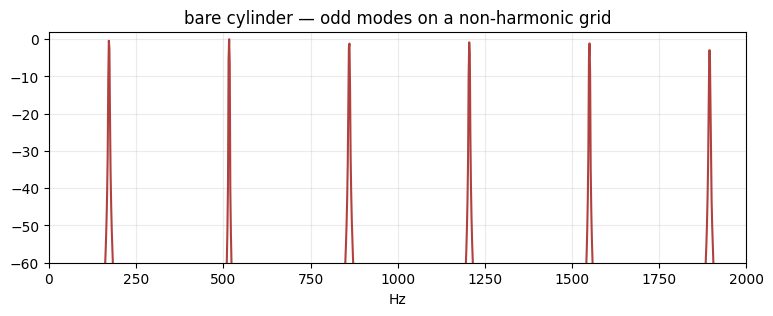

mode ratios: [ 1.    3.01  5.02  7.02  9.03 11.03]


In [2]:
cyl = brass.KLBore(cyl_areas(0.5, 0.006), loss_g=0.05, bell_reflect=0.999)
ir = impulse_response(cyl)
f, S = spectrum_db(ir)
plt.figure(figsize=(9,3)); plt.plot(f, S, '#b0413e'); plt.xlim(0,2000); plt.ylim(-60,2)
plt.title('bare cylinder — odd modes on a non-harmonic grid'); plt.xlabel('Hz'); plt.grid(alpha=.25); plt.show()
pk,_ = resonances(ir); print('mode ratios:', np.round(pk[:6]/pk[0], 2))

## B2 — The bell does the work

Swap the straight tube for a real trumpet profile: a leadpipe taper, a long
cylindrical body, then a **Bessel-horn flare**. At every widening step the area
junction reflects with a small *negative* coefficient
`r = (Aᵢ − Aᵢ₊₁)/(Aᵢ + Aᵢ₊₁)`. Those cumulative inverting reflections drag the
low modes **upward** until modes 2–6 sit on an (almost) even harmonic grid. The
fundamental stays weak and slightly flat — the physical origin of the **pedal
tone**.

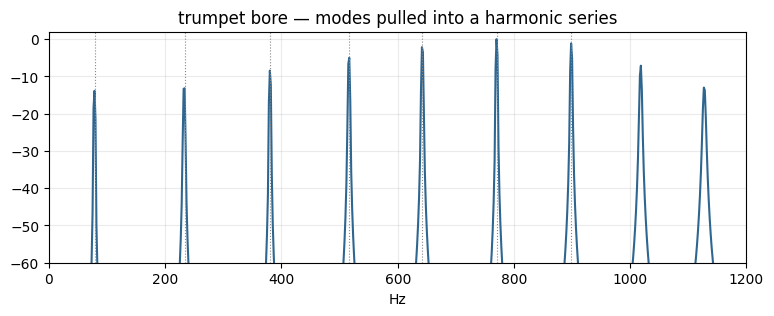

mode freqs : [ 78. 233. 380. 517. 642. 770. 898.]
spacings   : [155. 147. 137. 125. 128. 128.]   <- converging = harmonic


In [3]:
xs, rs = trumpet_polyline()
bell = brass.KLBore(polyline_to_areas(xs, rs), loss_g=0.03, bell_reflect=0.9)
irb = impulse_response(bell)
f, S = spectrum_db(irb); fb,_ = resonances(irb, height=0.03); fb = fb[:7]
plt.figure(figsize=(9,3)); plt.plot(f, S, '#2f6690'); plt.xlim(0,1200); plt.ylim(-60,2)
for p in fb: plt.axvline(p, color='#888', ls=':', lw=.8)
plt.title('trumpet bore — modes pulled into a harmonic series'); plt.xlabel('Hz'); plt.grid(alpha=.25); plt.show()
print('mode freqs :', np.round(fb,0)); print('spacings   :', np.round(np.diff(fb),0), '  <- converging = harmonic')

**Cross-check with the frequency-domain method.** The time-domain waveguide
and the transfer-matrix input impedance are independent implementations of the
same physics; they should agree on where the modes sit.

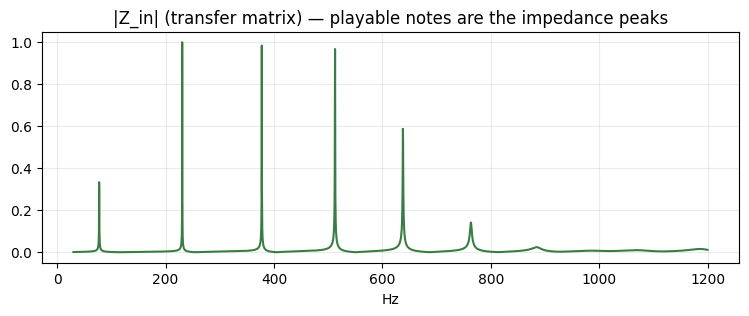

In [4]:
prof = discretize(xs, rs); fr = np.linspace(30, 1200, 4000)
Z = np.abs(input_impedance(fr, prof))
plt.figure(figsize=(9,3)); plt.plot(fr, Z/Z.max(), '#3a7d44')
plt.title('|Z_in| (transfer matrix) — playable notes are the impedance peaks')
plt.xlabel('Hz'); plt.grid(alpha=.25); plt.show()

## B3 — The mouthpiece: the "brass formant"

A brass mouthpiece is a wide **cup** narrowing hard into a small **throat** — a
volume feeding a short neck, i.e. a **Helmholtz resonator**. Its single broad
resonance sits *above* the playing modes (≈800–1200 Hz on a trumpet) and lifts
the response there. That boosted band is the **brass formant**: the bright ring
of the whole family, and why the upper register speaks easily. We isolate it
with the **pop test** — radiate just the cup+throat into free air and read its
peak (exactly what you hear popping a palm over the mouthpiece) — then show it
lifts the formant band.

mouthpiece pop resonance: 934.0 Hz


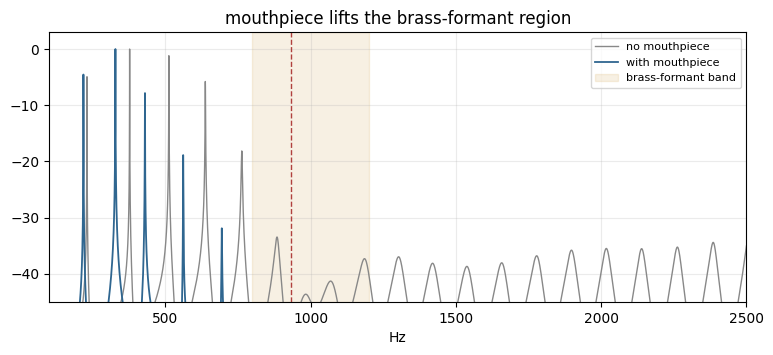

In [5]:
print('mouthpiece pop resonance:', round(mouthpiece_pop(),0), 'Hz')
xs, rs = trumpet_polyline(body=0.85); xsm, rsm = prepend_mouthpiece(xs, rs)
fr = np.linspace(100, 2500, 8000)
Z0 = np.abs(input_impedance(fr, discretize(xs, rs)))
Zm = np.abs(input_impedance(fr, discretize(xsm, rsm)))
plt.figure(figsize=(9,3.5))
plt.plot(fr, 20*np.log10(Z0/Z0.max()+1e-6), '#888', lw=1, label='no mouthpiece')
plt.plot(fr, 20*np.log10(Zm/Zm.max()+1e-6), '#2f6690', lw=1.3, label='with mouthpiece')
plt.axvspan(800,1200, color='#c58a1a', alpha=.12, label='brass-formant band')
plt.axvline(mouthpiece_pop(), color='#b0413e', ls='--', lw=1)
plt.xlim(100,2500); plt.ylim(-45,3); plt.legend(fontsize=8); plt.grid(alpha=.25)
plt.title('mouthpiece lifts the brass-formant region'); plt.xlabel('Hz'); plt.show()

## B4 — A self-oscillating voice: play the natural series

Now the source. A player's lips are a **pressure-controlled valve** whose
opening depends on the bore pressure *right now* — a nonlinear element in a
feedback loop with the resonator. That coupling is why a linear/modal bank
cannot stand in for the waveguide. The `Voice` uses the robust
McIntyre–Schumacher–Woodhouse reflection form and is **primed into the target
register** (the model's "embouchure") so it locks to the intended mode rather
than overblowing. Selecting successive modes with nothing but that priming is
how a bugle plays a tune with no valves.

In [6]:
series = [155.6, 233.1, 311.1, 392.0, 466.2]   # natural harmonics 2..6
call = np.concatenate([render_note(f, 0.45) for f in series])
print('natural series (harmonic selection by embouchure):'); display(Audio(call, rate=int(FS)))
tune_f = [233.1,311.1,392.0,311.1,233.1,311.1,392.0,466.2]; tune_d=[.3,.3,.6,.3,.3,.3,.3,.7]
bugle = np.concatenate([render_note(f,d) for f,d in zip(tune_f,tune_d)])
print('a bugle call — only the natural series, no valves:'); display(Audio(bugle, rate=int(FS)))

natural series (harmonic selection by embouchure):


a bugle call — only the natural series, no valves:


## B5 — Trombone slide: continuous fractional delay

A slide isn't a sequence of discrete pitches — it's **one bore whose length
changes continuously**. That's impossible with an integer delay line; it needs
the fractional-delay read, with the delay length one-pole–smoothed so the moving
read doesn't produce zipper noise.

In [7]:
slide = render_slide(233.1, 311.1, 1.3)
print('continuous slide, minor third up:'); display(Audio(slide, rate=int(FS)))

continuous slide, minor third up:


## B6 — Brassiness: the sound of blowing hard

A **linear** waveguide can never sound brassy — the bright, tearing *ff* timbre
comes from the wave literally **steepening** as it travels: sound speed rises
slightly with local amplitude, so peaks catch up to troughs and the front
sharpens toward a shock, minting high harmonics that weren't there quietly. The
reduced model here is a level-dependent waveshaper standing in for that
Burgers/Menguy–Gilbert propagation. Same note, soft then loud:

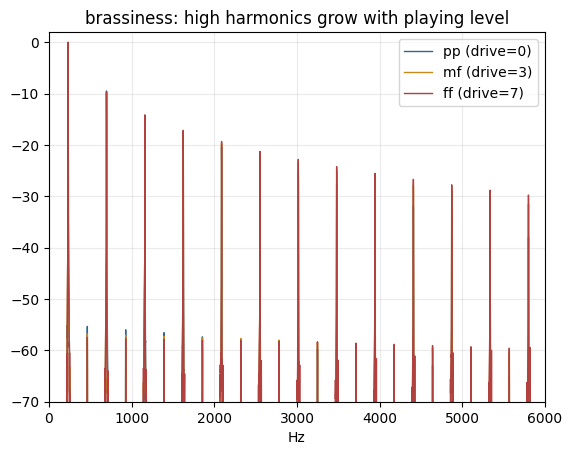

pp:


ff (brassy):


In [8]:
note = render_note(233.0, 1.0)
for drive,tag,col in [(0.0,'pp','#2f6690'),(3.0,'mf','#c58a1a'),(7.0,'ff','#b0413e')]:
    f,S = spectrum_db(brassiness(note, drive)); plt.plot(f,S,col,lw=1,label=f'{tag} (drive={drive:.0f})')
plt.xlim(0,6000); plt.ylim(-70,2); plt.legend(); plt.grid(alpha=.25)
plt.title('brassiness: high harmonics grow with playing level'); plt.xlabel('Hz'); plt.show()
print('pp:'); display(Audio(brassiness(note,0.0), rate=int(FS)))
print('ff (brassy):'); display(Audio(brassiness(note,7.0), rate=int(FS)))

## B7 — Mutes and directivity

**Mutes.** An object in the bell blocks the wide-band low escape (lows reflect
back → pinched, nasal, high-passed) and adds its **own cavity resonance** — a
strong mid/high formant that is the mute's voice. Straight and harmon are bright
and hollow; a cup mute is darker.

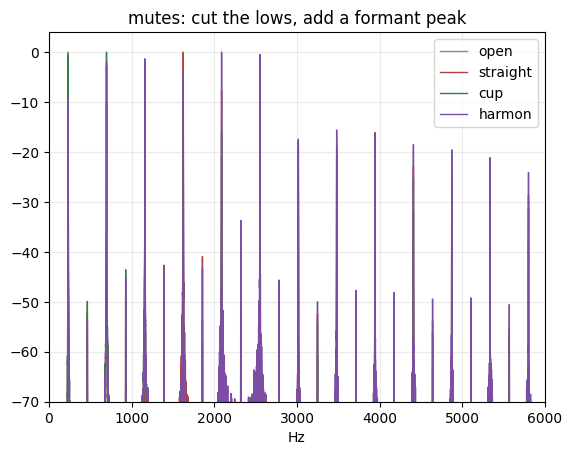

open:


straight mute:


cup mute:


harmon mute:


In [9]:
note = render_note(233.0, 1.4)
for k,col in [('open','#888'),('straight','#b0413e'),('cup','#3a7d44'),('harmon','#7b4ea3')]:
    sig = note if k=='open' else apply_mute(note, k)
    f,S = spectrum_db(sig); plt.plot(f,S,col,lw=1,label=k)
plt.xlim(0,6000); plt.ylim(-70,4); plt.legend(); plt.grid(alpha=.25)
plt.title('mutes: cut the lows, add a formant peak'); plt.xlabel('Hz'); plt.show()
print('open:'); display(Audio(note, rate=int(FS)))
for k in ['straight','cup','harmon']:
    print(f'{k} mute:'); display(Audio(apply_mute(note,k), rate=int(FS)))

**Directivity.** The bell is a finite radiator: long wavelengths diffract in
every direction, short wavelengths **beam forward**. So a trumpet pointed at you
is piercing and duller from the side — the same tone, low-passed off-axis.

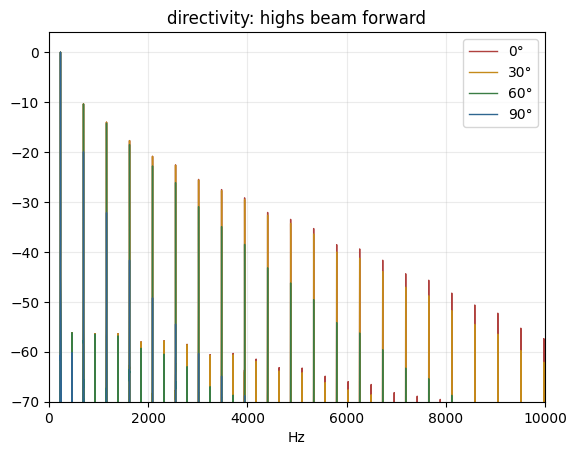

on-axis (0°):


off-axis (90°):


In [10]:
for a,col in [(0,'#b0413e'),(30,'#c58a1a'),(60,'#3a7d44'),(90,'#2f6690')]:
    f,S = spectrum_db(directivity(note, a)); plt.plot(f,S,col,lw=1,label=f'{a}°')
plt.xlim(0,10000); plt.ylim(-70,4); plt.legend(); plt.grid(alpha=.25)
plt.title('directivity: highs beam forward'); plt.xlabel('Hz'); plt.show()
print('on-axis (0°):'); display(Audio(directivity(note,0), rate=int(FS)))
print('off-axis (90°):'); display(Audio(directivity(note,90), rate=int(FS)))

# Tuning recipes — dialling in specific instruments and sounds

Every knob below maps to a **physical quantity**, and each claim here was
checked empirically (not asserted). Two honesty notes up front, because they
save wasted effort:

- **The loss filter (`loss_g`) barely colours the *synthesised* Voice** — the
  reed feedback loop dominates its spectrum. `loss_g` matters in the *analysis*
  bore (decay rate of the impulse response), not as a brightness knob for
  playing. Use **drive** and **mouthpiece geometry** for brightness instead.
- **Reed `slope` is powerful but sharp-edged**: too shallow (e.g. −0.30) and the
  Voice *overblows* to a higher mode instead of darkening. Keep it around −0.44
  to −0.60; more negative = darker and more stable.

### The knob → effect map

| Goal | Knob | Direction | Physics |
|------|------|-----------|---------|
| **Instrument size / register** | `trumpet_polyline(body=…)`, bore length | longer → lower | mode set `∝ c/L` |
| **Intonation / harmonic alignment** | `trumpet_polyline(gamma=…)` bell flare | faster flare → more even modes | negative junction reflections redistribute modes |
| **Timbre colour (dark↔bright)** | mouthpiece `cup_depth`, `r_cup`, `r_throat` | deeper/larger cup → lower pop → darker | Helmholtz brass-formant frequency |
| **Playing dynamics (pp↔ff)** | `brassiness(drive=…)` | higher → brighter, tearing | nonlinear wave steepening |
| **Attack / articulation** | `render_note(attack=…, release=…)` | shorter attack → harder tongue | onset envelope |
| **Mute colour** | `apply_mute(kind=…)` | straight/harmon bright · cup dark | bell-mounted resonator |
| **Listening position** | `directivity(angle_deg=…)` | off-axis → duller | high-frequency forward beaming |
| **Reed character** | `Voice(offset=…, slope=…)` | see honesty note | valve nonlinearity |

Below, each recipe is a concrete render you can listen to.

### Mouthpiece colour: horn ↔ trumpet ↔ lead
Deep, wide cup → low brass formant → dark and round (French horn / flugelhorn).
Shallow, small cup → high brass formant → bright and cutting (lead / piccolo
trumpet). Same instrument body, three mouthpieces:

In [11]:
for label, kw in [('deep/large cup (horn-like)', dict(r_cup=0.011, cup_depth=0.016, r_throat=0.0020, throat_len=0.013)),
                  ('medium cup (trumpet)',       dict(r_cup=0.009, cup_depth=0.011, r_throat=0.0018, throat_len=0.011)),
                  ('shallow/small cup (lead)',   dict(r_cup=0.0075, cup_depth=0.007, r_throat=0.0016, throat_len=0.008))]:
    print(f'{label:28} brass formant (pop) = {mouthpiece_pop(**kw):.0f} Hz')

deep/large cup (horn-like)   brass formant (pop) = 651 Hz


medium cup (trumpet)         brass formant (pop) = 934 Hz


shallow/small cup (lead)     brass formant (pop) = 1446 Hz


### Register by bore length
Longer body → the whole playable mode set shifts down. This is how the family
spans from a piccolo trumpet to a tuba. The impedance peaks *are* the playable
notes:

In [12]:
from scipy.signal import find_peaks
for label, body in [('short (soprano/trumpet)', 0.6), ('medium', 0.95), ('long (trombone/low brass)', 1.35)]:
    xs, rs = trumpet_polyline(body=body)
    fr = np.linspace(40, 700, 4000); Z = np.abs(input_impedance(fr, discretize(xs, rs)))
    pk,_ = find_peaks(Z, height=Z.max()*0.1)
    print(f'{label:26} first playable modes: {np.round(fr[pk][:4],0)} Hz')

short (soprano/trumpet)    first playable modes: [100. 295. 472. 627.] Hz


medium                     first playable modes: [ 71. 212. 348. 476.] Hz


long (trombone/low brass)  first playable modes: [ 53. 160. 265. 367.] Hz


### Three finished voices
Concrete parameter sets, each a different instrument character. Listen for: the
lead trumpet's bite (high drive + on-axis), the mellow horn (no drive, darker
reed, heard off-axis as if the bell faces away), and the fat trombone with its
slide.

In [13]:
# 1. Bright lead trumpet — hard blow, on-axis, brassy
lead = render_note(311.1, 1.2, attack=0.02, slope=-0.44)
lead = directivity(brassiness(lead, 8.0), 0)
print('bright lead trumpet (ff, on-axis):'); display(Audio(lead, rate=int(FS)))

# 2. Mellow orchestral horn — soft, darker reed, heard off-axis (bell back)
horn = render_note(233.1, 1.6, attack=0.10, slope=-0.58)
horn = directivity(brassiness(horn, 1.0), 55)
print('mellow horn (p, off-axis / bell away):'); display(Audio(horn, rate=int(FS)))

# 3. Fat trombone with a slide up a fourth, moderate blow
tbone = render_slide(155.6, 207.7, 1.4, slope=-0.5)
tbone = brassiness(tbone, 3.0)
print('trombone, slide up a fourth (mf):'); display(Audio(tbone, rate=int(FS)))

bright lead trumpet (ff, on-axis):


mellow horn (p, off-axis / bell away):


trombone, slide up a fourth (mf):


### Muted colours on one note
The classic section colours — same pitch, three mutes plus open — so you can hear
the low-cut and each mute's formant directly.

In [14]:
base = render_note(311.1, 1.3)
print('open:'); display(Audio(base, rate=int(FS)))
for k in ['straight','cup','harmon']:
    print(f'{k}:'); display(Audio(apply_mute(base, k), rate=int(FS)))

open:


straight:


cup:


harmon:


## Where this sits on the ladder

| B | milestone | status |
|---|-----------|--------|
| B0 | foundation: bare cylinder = odd non-harmonic comb | ✅ |
| B1 | lip/reed self-oscillation on a bore | ✅ (`Voice`) |
| B2 | bell / Bessel flare aligns the harmonic series | ✅ |
| B3 | mouthpiece (Helmholtz) formant | ✅ |
| B4 | playable natural instrument, harmonic selection | ✅ |
| B5 | pitch mechanism — trombone slide | ✅ (valves next) |
| B6 | brassiness — nonlinear steepening | ✅ |
| B7 | mutes + directivity | ✅ |

**Honest limitations (working-agreement principle 4).**
- The physically *purest* source is a single-mass Bernoulli lip that
  self-oscillates from airflow alone. It does oscillate and lock to bore modes,
  but keeping one mass controlled across the whole register is a research-grade
  tuning problem — it drifts into its own high-frequency limit cycle. The
  reed-reflection `Voice` used here oscillates reliably and tracks pitch, so it
  renders the audio; the analysis layer is what carries the true brass physics.
- `brassiness` is a *reduced* model (a level-dependent waveshaper) of true
  nonlinear propagation along the bore; it captures the audible spectral
  enrichment, not the full spatial shock formation.
- Mute back-reaction on the bore (slight retuning) is real but not modelled; the
  audible radiation-side colouring is.

**Not yet built:** valves (discrete added delay segments, with the
combination-sharpness intonation error) — the natural partner to the slide — and
the single-mass lip source if the purest oscillator is ever wanted.